In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from catboost import CatBoostClassifier


In [9]:
df=pd.read_csv("Data/all_seasons.csv")



In [12]:
career = df.groupby("player_name").agg({
    "gp": "sum",
    "pts": "mean",
    "reb": "mean",
    "ast": "mean",
    "net_rating": "mean",
    "usg_pct": "mean",
    "ts_pct": "mean",
    "draft_number": "first",
    "draft_round": "first"
}).reset_index()

In [18]:
numeric_cols = [
    "draft_number",
    "gp",
    "pts",
    "ast",
    "net_rating"
]

for col in numeric_cols:
    career[col] = pd.to_numeric(career[col], errors="coerce")
    
career["diamond"] = (
    (
        (career["draft_number"] >= 31)
    )
    &
    (career["gp"] >= 250)
    &
    (
        (career["pts"] >= 10)
        |
        (career["net_rating"] >= 3)
        |
        (career["ast"] >= 5)
    )
).astype(int)

In [ ]:
college=pd.read_csv("Data/CollegeBasketballPlayers2009-2021.csv")

merged = college.merge(
    career[["player_name", "diamond"]],
    on="player_name",
    how="inner"
)



/var/folders/2s/pmq2df492vgg1l49kmbj_zhr0000gn/T/ipykernel_12078/82852206.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  college=pd.read_csv("Data/CollegeBasketballPlayers2009-2021.csv")


diamond
0    2979
1      71
Name: count, dtype: int64

In [30]:
features = [
    "pts",
    "ast",
    "treb",
    "bpm",
    "obpm",
    "dbpm",
    "usg",
    "TS_per",
    "stl",
    "blk"
]


X = merged[features]
y = merged["diamond"]

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

print(classification_report(y_test, pred_log))

              precision    recall  f1-score   support

           0       0.98      0.55      0.70       596
           1       0.03      0.64      0.06        14

    accuracy                           0.55       610
   macro avg       0.51      0.59      0.38       610
weighted avg       0.96      0.55      0.69       610



In [ ]:


pred_prob = log_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, pred_prob)

print("ROC AUC:", auc)

ROC AUC: 0.5278044103547459


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       596
           1       0.00      0.00      0.00        14

    accuracy                           0.98       610
   macro avg       0.49      0.50      0.49       610
weighted avg       0.95      0.98      0.97       610

ROC AUC: 0.6725790987535955


/opt/anaconda3/envs/pythonds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/pythonds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/pythonds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

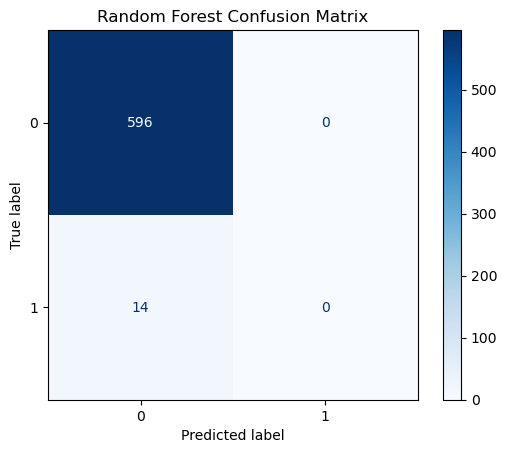

In [41]:

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

pred_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf))

auc_rf = roc_auc_score(y_test, pred_prob_rf)

print("ROC AUC:", auc_rf)

cm = confusion_matrix(y_test, pred_rf)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       596
           1       0.04      0.07      0.05        14

    accuracy                           0.93       610
   macro avg       0.51      0.51      0.51       610
weighted avg       0.96      0.93      0.94       610

ROC AUC: 0.6810882070949185


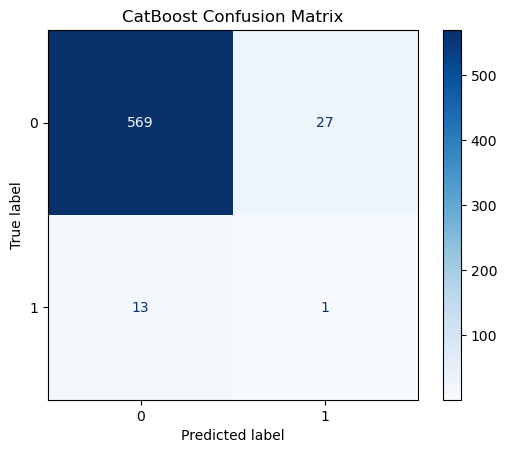

In [44]:


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0,
    auto_class_weights="Balanced"
)

cat_model.fit(X_train, y_train)

pred_prob_cat = cat_model.predict_proba(X_test)[:, 1]

pred_cat = (pred_prob_cat >= 0.2).astype(int)

print(classification_report(y_test, pred_cat))

auc_cat = roc_auc_score(y_test, pred_prob_cat)

print("ROC AUC:", auc_cat)

cm = confusion_matrix(y_test, pred_cat)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("CatBoost Confusion Matrix")

plt.show()

In [46]:
example_player = pd.DataFrame([{
    "pts": 18.5,
    "ast": 6.2,
    "treb": 5.1,
    "bpm": 8.4,
    "obpm": 5.2,
    "dbpm": 2.1,
    "usg": 24.3,
    "TS_per": 0.61,
    "stl": 1.8,
    "blk": 0.7
}])

example_player = example_player[features]

example_player_imputed = imputer.transform(example_player)

diamond_prob = cat_model.predict_proba(example_player_imputed)[0][1]

print("Diamond Probability:", diamond_prob)
print("Prediction:", int(diamond_prob >= 0.2))

Diamond Probability: 0.0005375309983534946
Prediction: 0
